In [1]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

In [51]:
M = 1000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

## Electric modes ($H=H_z$)

In [54]:
l = 1
j_y = jv(l, y); y_x = yv(l, x); 
j_yprime = jvp(l, y);
y_xprime = yvp(l, x)
sigmas_passive_sink = 1j*(m*j_y/j_yprime - y_x/y_xprime)
sigmas_passive_sink_real = sigmas_passive_sink.real
sigmas_passive_sink_imaginary = sigmas_passive_sink.imag
s_passive_sink_s = h_z_cpa(l, x, epsilon, -1j*(sigmas_passive_sink_real + 1j*sigmas_passive_sink_imaginary))

j_x = jv(l, x);
j_xprime = jvp(l, x);
prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

sigmas_cpa = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_cpa_real = sigmas_cpa[0, :]
sigmas_cpa_imaginary = sigmas_cpa[1, :]
s_cpa_s = h_z_cpa(l, x, epsilon, -1j*(sigmas_cpa_real + 1j*sigmas_cpa_imaginary))
s_cpa_no_dissipation_s = h_z_cpa(l, x, epsilon, -1j*(1j*sigmas_cpa_imaginary))

In [55]:
print("Maximum CPA s: ", np.abs(s_cpa_s).max())
print("Minimum CPA s: ", np.abs(s_cpa_s).min(), "\n")
print("Maximum passive sink s: ", np.abs(s_passive_sink_s).max())
print("Minimum passive sink s: ", np.abs(s_passive_sink_s).min(), "\n")
print("Maximum cpa s (without dissipation): ", np.abs(s_passive_sink_s).max())
print("Minimum cpa sink s (without dissipation): ", np.abs(s_passive_sink_s).min())

Maximum CPA s:  1.2018405518104015e-10
Minimum CPA s:  1.7366415383504546e-18 

Maximum passive sink s:  1.0
Minimum passive sink s:  0.9999999999999999 

Maximum cpa s (without dissipation):  1.0
Minimum cpa sink s (without dissipation):  0.9999999999999999


## Below, we plot the imaginary parts of the conductivities corresponding to CPA and passive sink as a function of $kR$. In the small $kR$ limit, these converge to one another. We also plot the phase of the scattering coefficient corresponding to the CPA imaginary conductivity (neglecting the effect of the real part of the conductivity). As seen, for $kR<<1$, the phase approaches $\pi$, as expected. 

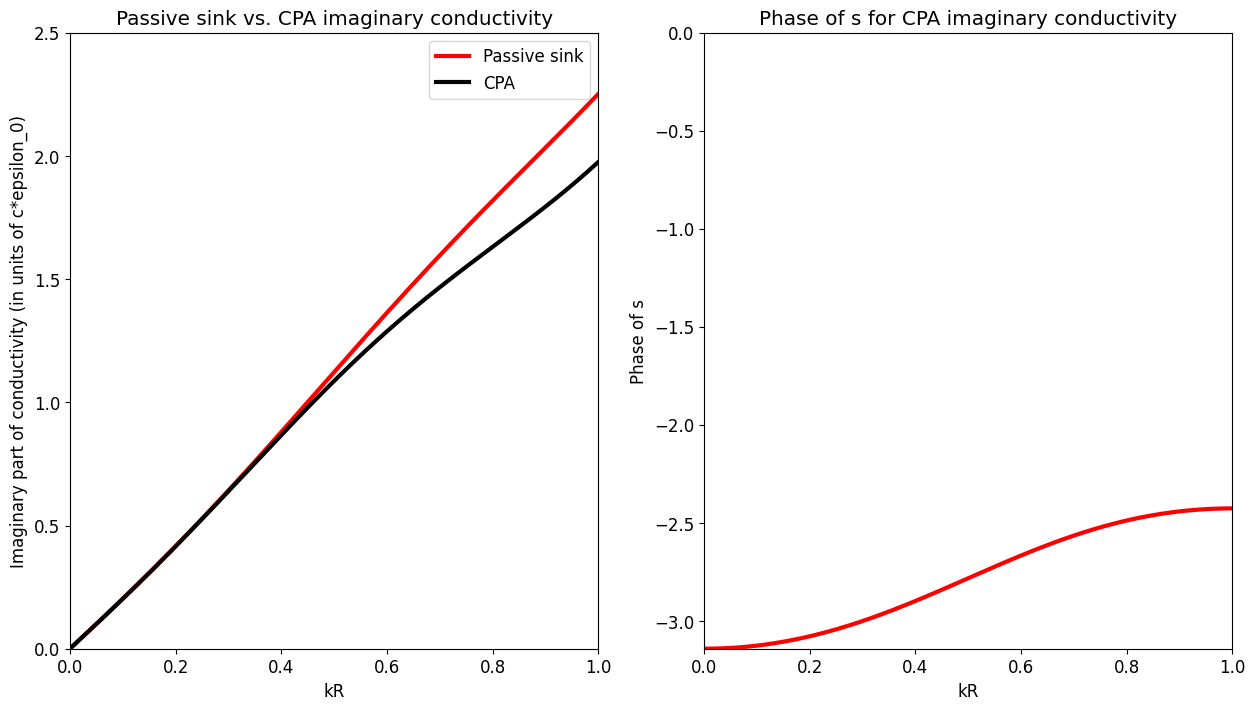

In [59]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.plot(x, sigmas_passive_sink_imaginary, color="red", label="Passive sink", linewidth=3)
ax1.plot(x, sigmas_cpa_imaginary, color="black", label="CPA", linewidth=3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 2.5)
ax1.set_xlabel("kR")
ax1.set_ylabel("Imaginary part of conductivity (in units of c*epsilon_0)")
ax1.legend();
ax1.set_title("Passive sink vs. CPA imaginary conductivity")

ax2.plot(x, angle(s_cpa_no_dissipation_s), color="red", linewidth=3)
ax2.set_ylim(-pi, 0)
ax2.set_xlim(0, 1);
ax2.set_title("Phase of s for CPA imaginary conductivity")
ax2.set_ylabel("Phase of s")
ax2.set_xlabel("kR");

### We sweep the imaginary part of the conductivity through the point at which $s=-1$

In [30]:
x_idx = 100; N = 1200
# We sweep from 1/2 to 1.5 times the imaginary conductivity corresponding to the passive sink
sigmas_off_passive_sink = 1j*linspace(1/2, 1.5, N) * sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = h_z_cpa(l, x[x_idx], epsilon, -1j*sigmas_off_passive_sink)

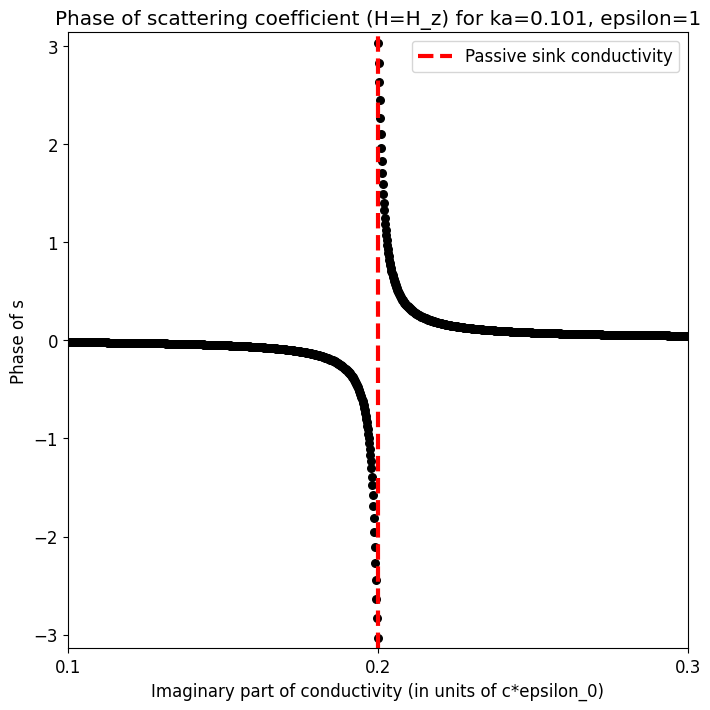

In [31]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(8, 8))
sigmas_off_passive_sink_imag = sigmas_off_passive_sink.imag
min_x = sigmas_off_passive_sink_imag.min()
max_x = sigmas_off_passive_sink_imag.max()
ax.scatter(sigmas_off_passive_sink_imag, angle(s_off_passive_sink), color="black", s=30)
ax.set_xlim(min_x, max_x)
ax.vlines([sigmas_passive_sink_imaginary[x_idx]], -pi, pi, color="red", linestyle="dashed", linewidth=3, label="Passive sink conductivity")
ax.set_ylim(-pi, pi)
ax.set_xlabel("Imaginary part of conductivity (in units of c*epsilon_0)");
ax.set_ylabel("Phase of s");
ax.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax.set_title(f"Phase of scattering coefficient (H=H_z) for ka={x[x_idx].round(3)}, epsilon={epsilon}");
ax.legend();

### Now we plot $s$ as a the real part of the surface conductivity is sweeped. We expect that $|s|<1$ throughout the range due to absorption.

In [32]:
x_idx = 120
N = 10000
sigmas_off_passive_sink = linspace(0, 0.005, N) + 1j*sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = h_z_cpa(l, x[x_idx], epsilon, -1j*sigmas_off_passive_sink)

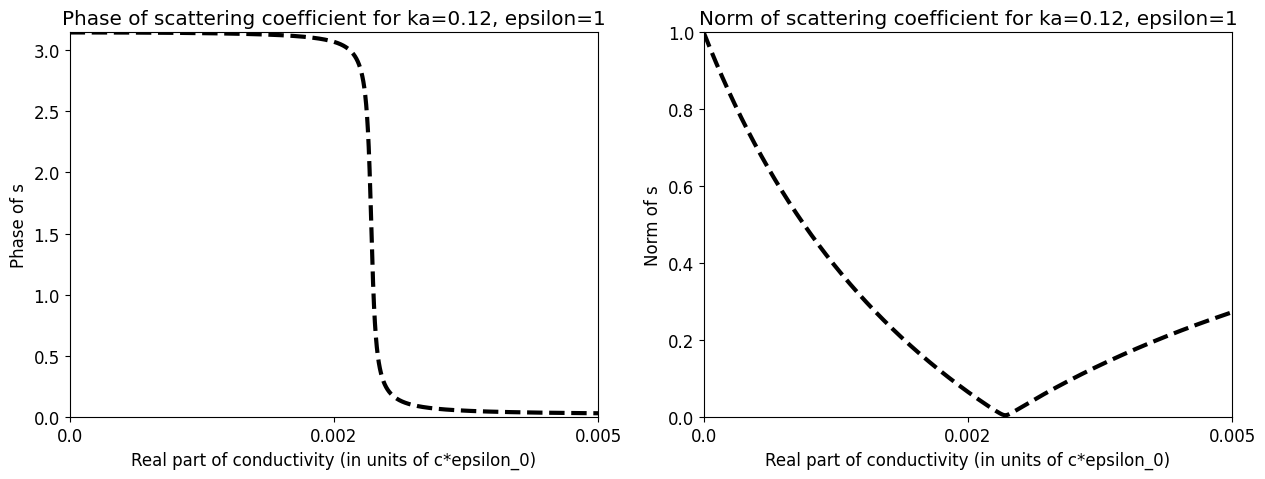

In [33]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sigmas_off_passive_sink_real = sigmas_off_passive_sink.real
min_x = sigmas_off_passive_sink_real.min()
max_x = sigmas_off_passive_sink_real.max()
ax1.plot(sigmas_off_passive_sink_real, angle(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(min_x, max_x)
ax1.set_ylim(0, pi)
ax1.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax1.set_ylabel("Phase of s");
ax1.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax1.set_title(f"Phase of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");

ax2.plot(sigmas_off_passive_sink_real, np.abs(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax2.set_xlim(min_x, max_x)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax2.set_ylabel("Norm of s");
ax2.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax2.set_title(f"Norm of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");

## Magnetic modes ($E=E_z$)

In [34]:
l = 1
j_y = jv(l, y); 
y_x = yv(l, x); 
j_yprime = jvp(l, y);
y_xprime = yvp(l, x)
sigmas_passive_sink = 1j*(y_xprime/y_x-m*j_yprime/j_y)
sigmas_passive_sink_real = sigmas_passive_sink.real
sigmas_passive_sink_imaginary = sigmas_passive_sink.imag
s_passive_sink_s = e_z_cpa(l, x, epsilon, -1j*(sigmas_passive_sink_real + 1j*sigmas_passive_sink_imaginary))

j_x = jv(l, x);
j_xprime = jvp(l, x);
y_xprime = yvp(l, x)
prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])
sigmas_cpa = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_cpa_real = sigmas_cpa[0, :]
sigmas_cpa_imaginary = sigmas_cpa[1, :]

s_cpa_s = e_z_cpa(l, x, epsilon, -1j*(sigmas_cpa_real + 1j*sigmas_cpa_imaginary))
s_cpa_no_dissipation_s = e_z_cpa(l, x, epsilon, -1j*(1j*sigmas_cpa_imaginary))

In [35]:
print("Maximum CPA s: ", np.abs(s_cpa_s).max())
print("Minimum CPA s: ", np.abs(s_cpa_s).min(), "\n")
print("Maximum passive sink s: ", np.abs(s_passive_sink_s).max())
print("Minimum passive sink s: ", np.abs(s_passive_sink_s).min(), "\n")
print("Maximum cpa s (without dissipation): ", np.abs(s_passive_sink_s).max())
print("Minimum cpa sink s (without dissipation): ", np.abs(s_passive_sink_s).min())

Maximum CPA s:  3.8981879769805216e-11
Minimum CPA s:  4.160778315709861e-19 

Maximum passive sink s:  1.0
Minimum passive sink s:  0.9999999999999999 

Maximum cpa s (without dissipation):  1.0
Minimum cpa sink s (without dissipation):  0.9999999999999999


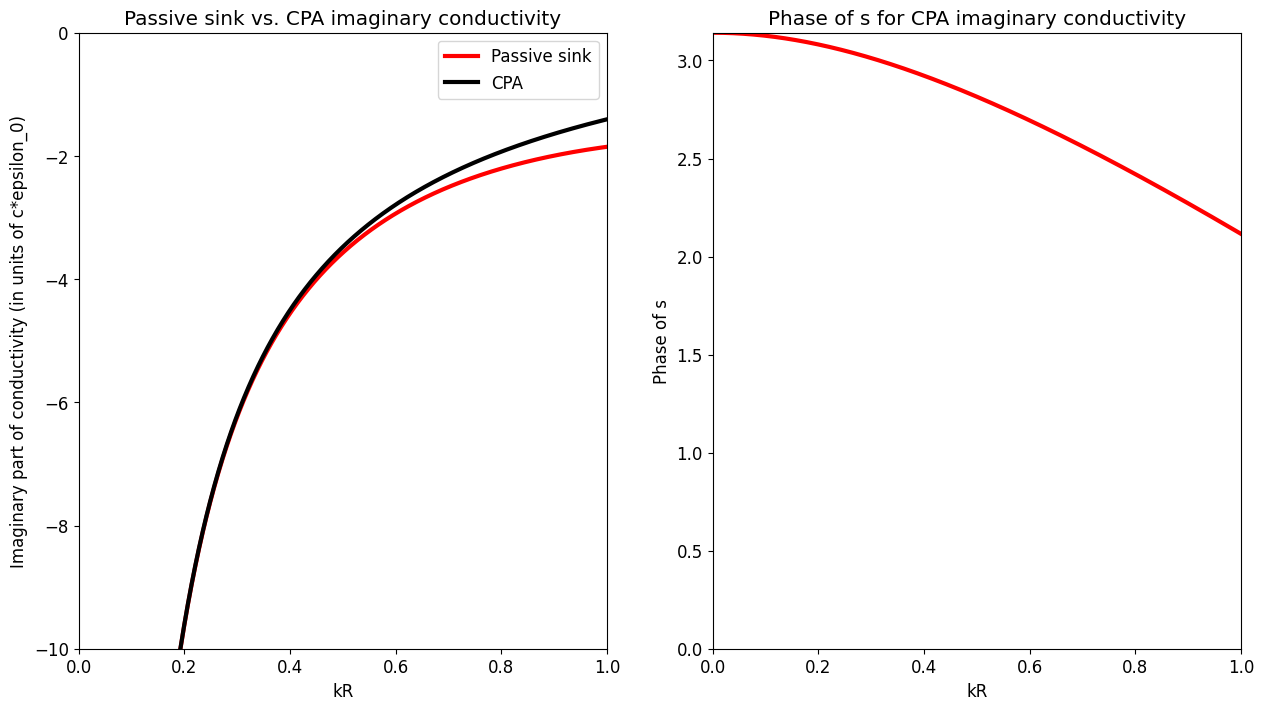

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.plot(x, sigmas_passive_sink_imaginary, color="red", label="Passive sink", linewidth=3)
ax1.plot(x, sigmas_cpa_imaginary, color="black", label="CPA", linewidth=3)
ax1.set_xlim(0, 1)
ax1.set_ylim(-10, 0)
ax1.set_xlabel("kR")
ax1.set_ylabel("Imaginary part of conductivity (in units of c*epsilon_0)")
ax1.legend();
ax1.set_title("Passive sink vs. CPA imaginary conductivity")

ax2.plot(x, angle(s_cpa_no_dissipation_s), color="red", linewidth=3)
ax2.set_ylim(0, pi)
ax2.set_xlim(0, 1);
ax2.set_title("Phase of s for CPA imaginary conductivity")
ax2.set_ylabel("Phase of s")
ax2.set_xlabel("kR");

In [45]:
x_idx = 100; N = 1200
# We sweep from 1/2 to 1.5 times the imaginary conductivity corresponding to the passive sink
sigmas_off_passive_sink = 1j*linspace(1/2, 1.5, N) * sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = e_z_cpa(l, x[x_idx], epsilon, -1j*sigmas_off_passive_sink)

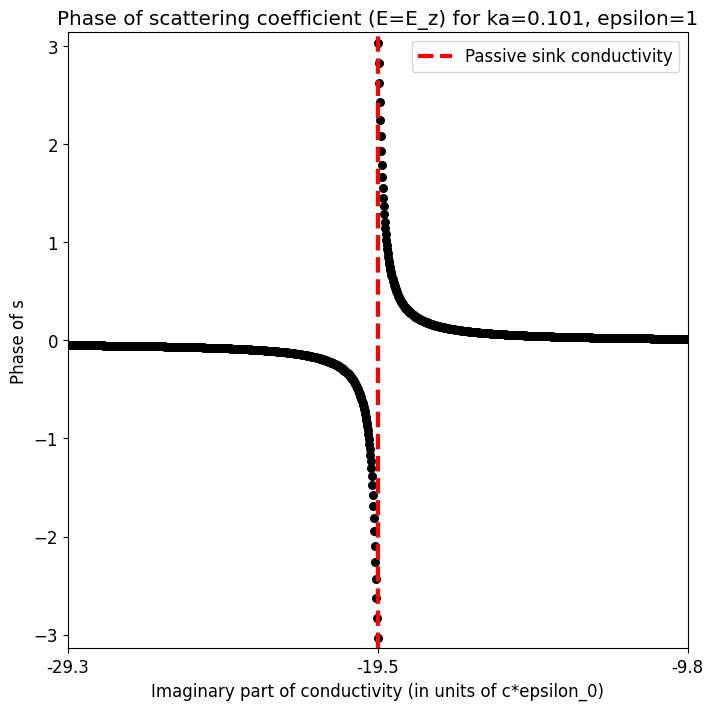

In [46]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(8, 8))
sigmas_off_passive_sink_imag = sigmas_off_passive_sink.imag
min_x = sigmas_off_passive_sink_imag.min()
max_x = sigmas_off_passive_sink_imag.max()
ax.scatter(sigmas_off_passive_sink_imag, angle(s_off_passive_sink), color="black", s=30)
ax.set_xlim(min_x, max_x)
ax.vlines([sigmas_passive_sink_imaginary[x_idx]], -pi, pi, color="red", linestyle="dashed", linewidth=3, label="Passive sink conductivity")
ax.set_ylim(-pi, pi)
ax.set_xlabel("Imaginary part of conductivity (in units of c*epsilon_0)");
ax.set_ylabel("Phase of s");
ax.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax.set_title(f"Phase of scattering coefficient (E=E_z) for ka={x[x_idx].round(3)}, epsilon={epsilon}");
ax.legend();

In [47]:
x_idx = 100
N = 10000
sigmas_off_passive_sink = linspace(0, 0.25, N) + 1j*sigmas_passive_sink_imaginary[x_idx]
s_off_passive_sink = e_z_cpa(l, x[x_idx], epsilon, -1j*sigmas_off_passive_sink)

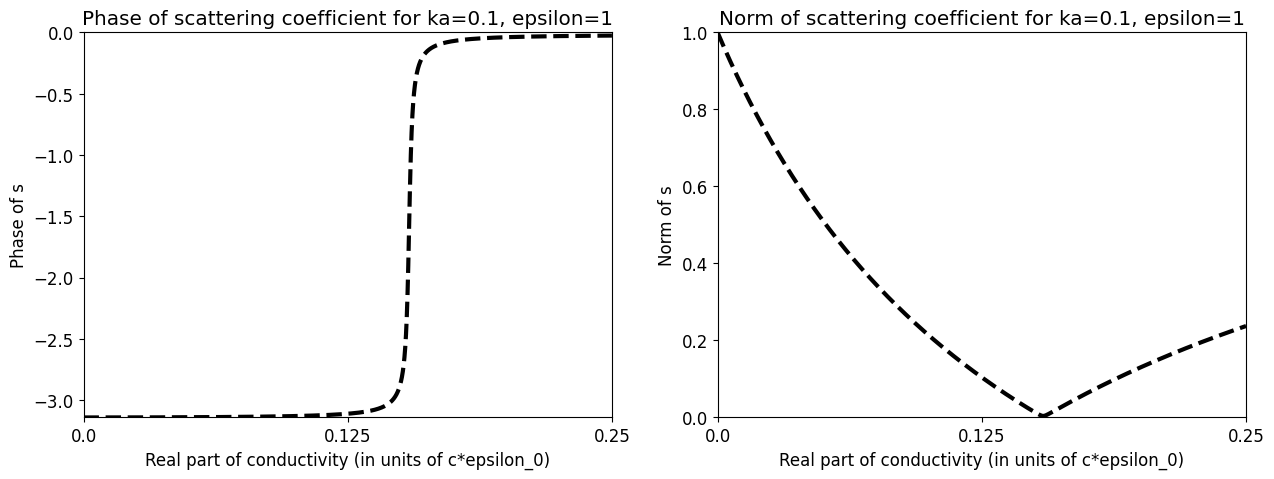

In [48]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sigmas_off_passive_sink_real = sigmas_off_passive_sink.real
min_x = sigmas_off_passive_sink_real.min()
max_x = sigmas_off_passive_sink_real.max()
ax1.plot(sigmas_off_passive_sink_real, angle(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(min_x, max_x)
ax1.set_ylim(-pi, 0)
ax1.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax1.set_ylabel("Phase of s");
ax1.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax1.set_title(f"Phase of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");

ax2.plot(sigmas_off_passive_sink_real, np.abs(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax2.set_xlim(min_x, max_x)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax2.set_ylabel("Norm of s");
ax2.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 3));
ax2.set_title(f"Norm of scattering coefficient for ka={x[x_idx].round(2)}, epsilon={epsilon}");